## Exercise 2.1 Unsupervised Learning Algorithms

#### This script follows the structure below

## 1.Importing libraries
## 2.Data Wrangling
## 3. Supervised Learning Algorithm - Decision Tree
### 3.1 Supervised Learning Algorithm - Decision Tree - Confusion Matrix
## 4. Supervised Learning Algorithm - Artifical Neural Netwrok (ANNs)
### 4.1 Comparison between scaled and unscaled data
### 4.2 Run the ANN Model

# 1. Importing libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.pyplot import figure

In [7]:
# Creating a path for importing the climate data set

path = r'/Users/daniel/Desktop/Ordner/Data Analyst/Data Analytics Course/Data Specialization/Achievement 1/Data Sets'

In [9]:
# Import the data set

df_weather= pd.read_csv(os.path.join(path, 'Dataset-weather-prediction-dataset-processed.csv'),index_col = False)

df_answer = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'),index_col = False)

# 2. Data Wrangling

In [11]:
# Show all the columns in the data set
pd.set_option('display.max_columns', 200)

# Show all the rows in the data set
pd.set_option('display.max_rows', None)

#### Dataset Weather

In [13]:
# Check for correct import 

df_weather.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_wind_speed,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_wind_speed,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_snow_depth,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,GDANSK_cloud_cover,GDANSK_humidity,GDANSK_precipitation,GDANSK_snow_depth,GDANSK_temp_mean,GDANSK_temp_min,GDANSK_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_snow_depth,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_wind_speed,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_wind_speed,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_wind_speed,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_wind_speed,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_snow_depth,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_wind_speed,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_snow_depth,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,ROMA_cloud_cover,ROMA_wind_speed,ROMA_humidity,ROMA_pressure,ROMA_sunshine,ROMA_temp_mean,SONNBLICK_cloud_cover,SONNBLICK_wind_speed,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,6.5,0.8,10.9,1,0.81,1.0195,0.88,0.00,7.0,3.7,-0.9,7.9,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1,7,7.7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0,8,5.4,0.83,1.0161,0.12,0.08,0,0.0,10.0,7.0,11.5,8,0.91,0.00,0,0.8,-0.3,1.6,7,0.91,1.0010,0.13,0.22,0,0.0,10.6,9.4,8.3,2.9,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4,8,1.4,1.00,1.0173,0.20,0.00,0.0,-0.6,-1.9,0.5,7,8.7,0.83,1.0063,0.22,0.32,1.0,9.5,8.5,11.1,6,0.0,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8,5,0.67,0.20,0.10,0,0.0,6.9,1.1,10.4,8,4.0,0.98,0.9978,0.04,1.14,0,0.0,4.9,3.8,5.9,3,2.6,0.73,1.0152,7.1,7.8,4,4.5,0.73,1.0304,0.48,0.01,2.3,-5.9,-8.5,-3.2,5,1.0114,0.05,0.32,0.0,4.2,2.2,4.9,3.8,0.76,1.0169,1.54,0.44,10.0,7.8,12.2,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84

In [15]:
# Check for data frame shape

df_weather.shape

(22950, 170)

In [17]:
# Check for missing values

df_weather.isnull().sum()

DATE                           0
MONTH                          0
BASEL_cloud_cover              0
BASEL_wind_speed               0
BASEL_humidity                 0
BASEL_pressure                 0
BASEL_global_radiation         0
BASEL_precipitation            0
BASEL_snow_depth               0
BASEL_sunshine                 0
BASEL_temp_mean                0
BASEL_temp_min                 0
BASEL_temp_max                 0
BELGRADE_cloud_cover           0
BELGRADE_humidity              0
BELGRADE_pressure              0
BELGRADE_global_radiation      0
BELGRADE_precipitation         0
BELGRADE_sunshine              0
BELGRADE_temp_mean             0
BELGRADE_temp_min              0
BELGRADE_temp_max              0
BUDAPEST_cloud_cover           0
BUDAPEST_humidity              0
BUDAPEST_pressure              0
BUDAPEST_global_radiation      0
BUDAPEST_precipitation         0
BUDAPEST_sunshine              0
BUDAPEST_temp_mean             0
BUDAPEST_temp_min              0
BUDAPEST_t

In [19]:
# Check for duplicate values

duplicate_value = df_weather.duplicated()

print(f"Total duplicate value: {duplicate_value.sum()}")

Total duplicate value: 0


In [23]:
# Check the basic statistic values
df_weather.describe()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_wind_speed,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_wind_speed,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_snow_depth,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,GDANSK_cloud_cover,GDANSK_humidity,GDANSK_precipitation,GDANSK_snow_depth,GDANSK_temp_mean,GDANSK_temp_min,GDANSK_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_snow_depth,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_wind_speed,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_wind_speed,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_wind_speed,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_wind_speed,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_snow_depth,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_wind_speed,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_snow_depth,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,ROMA_cloud_cover,ROMA_wind_speed,ROMA_humidity,ROMA_pressure,ROMA_sunshine,ROMA_temp_mean,SONNBLICK_cloud_cover,SONNBLICK_wind_speed,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
count,2.295000e+04,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,22950.000000,229

In [ ]:
# Change the data type for the data column

df_weather["DATE"] = pd.to_datetime(df_weather["DATE"].astype(str), format='%Y%m%d')

In [ ]:
#Check for correct data type transformation
df_weather.head()

In [87]:
# Cutting down the dataframe to investigate a certain decade
df_2020_org = df_weather[(df_complete["DATE"] >= "2020-01-01") & (df_weather["DATE"] <= "2020-12-31")]
print(df_2020_org)

            DATE  MONTH  BASEL_cloud_cover  BASEL_wind_speed  BASEL_humidity  \
21915 2020-01-01      1                  0               1.7            0.87   
21916 2020-01-02      1                  0               3.1            0.87   
21917 2020-01-03      1                  7               2.2            0.81   
21918 2020-01-04      1                  6               2.3            0.79   
21919 2020-01-05      1                  0               0.9            0.85   
21920 2020-01-06      1                  0               2.1            0.88   
21921 2020-01-07      1                  7               1.3            0.92   
21922 2020-01-08      1                  7               1.8            0.86   
21923 2020-01-09      1                  4               2.2            0.68   
21924 2020-01-10      1                  6               2.4            0.76   
21925 2020-01-11      1                  6               1.2            0.85   
21926 2020-01-12      1                 

In [130]:
# Create a subset from the weather data

df_weather_2020 = df_2020_org[['BASEL_temp_mean',
                           'BASEL_temp_min',
                           'BASEL_temp_max',
                           'BELGRADE_temp_mean',
                           'BELGRADE_temp_min',
                           'BELGRADE_temp_max',
                           'BUDAPEST_temp_mean',
                           'BUDAPEST_temp_min',
                           'BUDAPEST_temp_max',
                           'DEBILT_temp_mean',
                           'DEBILT_temp_min',
                           'DEBILT_temp_max',
                           'DUSSELDORF_temp_mean',
                           'DUSSELDORF_temp_min',
                           'DUSSELDORF_temp_max',
                           'HEATHROW_temp_mean',
                           'HEATHROW_temp_min',
                           'HEATHROW_temp_max',
                           'KASSEL_temp_mean',
                           'KASSEL_temp_min',
                           'KASSEL_temp_max',
                           'LJUBLJANA_temp_mean',
                           'LJUBLJANA_temp_min',
                           'LJUBLJANA_temp_max',
                           'MAASTRICHT_temp_mean',
                           'MAASTRICHT_temp_min',
                           'MAASTRICHT_temp_max',
                           'MADRID_temp_mean',
                           'MADRID_temp_min',
                           'MADRID_temp_max',
                           'MUNCHENB_temp_mean',
                           'MUNCHENB_temp_min',
                           'MUNCHENB_temp_max',
                           'OSLO_temp_mean',
                           'OSLO_temp_min',
                           'OSLO_temp_max',
                           'SONNBLICK_temp_mean',
                           'SONNBLICK_temp_min',
                           'SONNBLICK_temp_max',
                           'STOCKHOLM_temp_mean',
                           'STOCKHOLM_temp_min',
                           'STOCKHOLM_temp_max',
                           'VALENTIA_temp_mean',
                           'VALENTIA_temp_min',
                           'VALENTIA_temp_max']].copy()

In [132]:
df_weather_2020.head()

,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
21915,-0.4,-3.4,3.2,2.0,-1.4,5.4,3.8,1.7,7.5,0.8,-0.2,1.8,1.3,-1.2,3.7,4.9,1.7,11.0,9.1,5.4,13.1,-0.6,-4.4,5.6,-0.6,-3.2,2.9,6.6,1.9,11.2,0.8,-2.6,4.9,1.9,-1.8,3.8,-6.1,-8.4,-3.8,3.5,1.2,5.2,10.7,7.9,13.5
21916,0.1,-2.0,3.0,2.6,-0.9,6.1,1.8,-0.2,6.1,3.9,1.3,7.4,2.4,-0.8,5.9,7.8,4.7,10.0,9.1,5.4,13.1,-2.7,-4.2,2.4,3.5,-0.6,7.4,6.0,1.6,10.5,-1.5,-4.6,4.1,4.1,0.0,6.2,-5.4,-7.1,-3.7,5.8,5.0,6.8,10.7,7.9,13.5
21917,5.3,0.8,10.1,0.7,-3.0,4.5,-1.6,-3.5,0.8,7.6,4.3,9.9,7.7,3.9,9.9,9.0,8.0,9.0,9.1,5.4,13.1,-1.0,-5.0,4.2,7.5,3.5,9.4,3.8,1.5,6.0,3.5,-4.2,8.4,4.5,1.3,7.0,-5.0,-8.1,-1.9,5.4,4.3,8.3,10.7,7.9,13.5
21918,6.0,2.3,8.8,-0.6,-3.4,2.2,2.7,-2.3,6.8,6.7,4.0,8.1,5.1,1.4,7.3,5.6,2.2,9.0,9.1,5.4,13.1,1.6,-3.9,5.5,5.0,2.5,6.9,7.0,2.8,11.2,4.3,2.8,7.0,0.7,-2.1,3.6,-9.8,-13.9,-5.6,2.4,1.6,4.4,10.7,7.9,13.5
21919,1.7,-1.5,6.1,3.4,2.0,4.9,2.9,2.2,5.6,6.9,5.9,7.6,6.4,5.7,7.2,7.5,6.0,8.9,9.1,5.4,13.1,0.6,-1.8,7.5,5.9,5.2,7.0,6.2,1.5,10.9,2.5,-1.3,4.7,-0.1,-3.6,2.5,-14.5,-15.7,-13.3,0.1,-1.5,1.9,10.7,7.9,13.5


# 3. Data Scaling

In [28]:
# Drop unneccsary date and month column

df_climate_sub = df_weather.drop(['DATE','MONTH'], axis=1)
df_climate_sub.head()

,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_wind_speed,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_wind_speed,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_snow_depth,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,GDANSK_cloud_cover,GDANSK_humidity,GDANSK_precipitation,GDANSK_snow_depth,GDANSK_temp_mean,GDANSK_temp_min,GDANSK_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_snow_depth,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_wind_speed,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_wind_speed,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_wind_speed,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_wind_speed,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_snow_depth,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_wind_speed,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_snow_depth,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,ROMA_cloud_cover,ROMA_wind_speed,ROMA_humidity,ROMA_pressure,ROMA_sunshine,ROMA_temp_mean,SONNBLICK_cloud_cover,SONNBLICK_wind_speed,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,2.1,0.85,1.018,0.32,0.09,0,0.7,6.5,0.8,10.9,1,0.81,1.0195,0.88,0.00,7.0,3.7,-0.9,7.9,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1,7,7.7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0,8,5.4,0.83,1.0161,0.12,0.08,0,0.0,10.0,7.0,11.5,8,0.91,0.00,0,0.8,-0.3,1.6,7,0.91,1.0010,0.13,0.22,0,0.0,10.6,9.4,8.3,2.9,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4,8,1.4,1.00,1.0173,0.20,0.00,0.0,-0.6,-1.9,0.5,7,8.7,0.83,1.0063,0.22,0.32,1.0,9.5,8.5,11.1,6,0.0,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8,5,0.67,0.20,0.10,0,0.0,6.9,1.1,10.4,8,4.0,0.98,0.9978,0.04,1.14,0,0.0,4.9,3.8,5.9,3,2.6,0.73,1.0152,7.1,7.8,4,4.5,0.73,1.0304,0.48,0.01,2.3,-5.9,-8.5,-3.2,5,1.0114,0.05,0.32,0.0,4.2,2.2,4.9,3.8,0.76,1.0169,1.54,0.44,10.0,7.8,12.2,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,6.1,3.3,10

In [30]:
#Create scaler object using StandardScaler from sklearn.preprocessing
#StandardScaler assumes data is normally distributed and scales with a distribution
#Around 0 and standard deviation of 1. Scaling happens independently with each variable.

scaler = StandardScaler()

In [32]:
#Create new df with scaled data

df_scaled = pd.DataFrame(scaler.fit_transform(df_climate_sub), columns=df_climate_sub.columns)
df_scaled.head()

,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_wind_speed,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_wind_speed,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_snow_depth,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,GDANSK_cloud_cover,GDANSK_humidity,GDANSK_precipitation,GDANSK_snow_depth,GDANSK_temp_mean,GDANSK_temp_min,GDANSK_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_snow_depth,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_wind_speed,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_wind_speed,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_wind_speed,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_wind_speed,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_snow_depth,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_wind_speed,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_snow_depth,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,ROMA_cloud_cover,ROMA_wind_speed,ROMA_humidity,ROMA_pressure,ROMA_sunshine,ROMA_temp_mean,SONNBLICK_cloud_cover,SONNBLICK_wind_speed,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,-0.902918,-0.528623,-0.845652,-0.478356,-1.206433,0.905270,0.321771,-0.743149,-0.371315,0.283983,-1.016876,-1.220210,-0.949203,-0.25524,-0.010098,-0.005876,-1.118537,-0.321868,-0.773378,-1.099163,-1.119431,-1.136839,0.713782,2.781340,0.357839,-1.232471,-1.197013,0.049619,-1.077312,-0.114356,0.263326,-0.411047,1.232526,0.815394,0.625746,-0.005606,-1.157575,-0.305938,-0.131344,-1.014908,-0.105836,0.060555,-0.410423,1.317965,0.660721,-0.348893,-0.268791,-0.927601,-0.667864,-1.158624,0.833387,1.332572,-1.376592,-1.187370,0.141032,-0.073841,-1.064721,-0.106469,0.393470,-1.038492,0.420616,0.449867,-0.801741,-1.069690,0.747355,-0.647708,-0.182904,-0.251893,-0.466503,1.205492,-0.02373,1.864672,-0.008724,-1.203514,-0.

#### Merging Back the Date column to create a subset for the unsupervised machine learning models

In [54]:
# Extract the date and month column from the original data frame
df_dates = df_weather[['DATE', 'MONTH']].copy()

In [56]:
df_dates.head()

,DATE,MONTH
0,1960-01-01,1
1,1960-01-02,1
2,1960-01-03,1
3,1960-01-04,1
4,1960-01-05,1


In [58]:
# Check for columns and rows

df_dates.shape

(22950, 2)

In [60]:
# Check for columns and rows

df_scaled.shape

(22950, 168)

In [66]:
# Merge the original and scaled data set, because I need the date and month column
# for looking at specific periods in team during further analysis

df_complete = df_dates.merge(df_scaled, left_index=True, right_index=True)

In [68]:
#Show new dataframe
df_complete.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_wind_speed,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_wind_speed,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_snow_depth,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,GDANSK_cloud_cover,GDANSK_humidity,GDANSK_precipitation,GDANSK_snow_depth,GDANSK_temp_mean,GDANSK_temp_min,GDANSK_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_snow_depth,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_wind_speed,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_wind_speed,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_wind_speed,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_wind_speed,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_snow_depth,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_wind_speed,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_snow_depth,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,ROMA_cloud_cover,ROMA_wind_speed,ROMA_humidity,ROMA_pressure,ROMA_sunshine,ROMA_temp_mean,SONNBLICK_cloud_cover,SONNBLICK_wind_speed,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,TOURS_wind_speed,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,1960-01-01,1,0.660514,-0.02793,0.826097,-0.001949,-1.101066,-0.265148,-0.179228,-0.902918,-0.528623,-0.845652,-0.478356,-1.206433,0.905270,0.321771,-0.743149,-0.371315,0.283983,-1.016876,-1.220210,-0.949203,-0.25524,-0.010098,-0.005876,-1.118537,-0.321868,-0.773378,-1.099163,-1.119431,-1.136839,0.713782,2.781340,0.357839,-1.232471,-1.197013,0.049619,-1.077312,-0.114356,0.263326,-0.411047,1.232526,0.815394,0.625746,-0.005606,-1.157575,-0.305938,-0.131344,-1.014908,-0.105836,0.060555,-0.410423,1.317965,0.660721,-0.348893,-0.268791,-0.927601,-0.667864,-1.158624,0.833387,1.332572,-1.376592,-1.187370,0.141032,-0.073841,-1.064721,-0.106469,0.393470,-1.038492,0.420616,0.449867,-0.801741,-1.069690,0.747355,-0.647708,-0.182904,-0.251893,-0.466503,1.205492,-0.02373,1.864672

In [70]:
# Cutting down the dataframe to investigate a certain decade

df_2020 = df_complete[(df_complete["DATE"] >= "2020-01-01") & (df_complete["DATE"] <= "2020-12-31")]
print(df_2020)

            DATE  MONTH  BASEL_cloud_cover  BASEL_wind_speed  BASEL_humidity  \
21915 2020-01-01      1          -2.248803         -0.573924        1.006770   
21916 2020-01-02      1          -2.248803          1.337054        1.006770   
21917 2020-01-03      1           0.660514          0.108568        0.464749   
21918 2020-01-04      1           0.244897          0.245067        0.284075   
21919 2020-01-05      1          -2.248803         -1.665912        0.826097   
21920 2020-01-06      1          -2.248803         -0.027930        1.097107   
21921 2020-01-07      1           0.660514         -1.119918        1.458455   
21922 2020-01-08      1           0.660514         -0.437426        0.916434   
21923 2020-01-09      1          -0.586336          0.108568       -0.709631   
21924 2020-01-10      1           0.244897          0.381565        0.013064   
21925 2020-01-11      1           0.244897         -1.256416        0.826097   
21926 2020-01-12      1           0.6605

In [77]:
df_2020.shape

(366, 170)

In [136]:
# Create a subset from the weather data

df_weather_2020_scal = df_2020[['BASEL_temp_mean',
                           'BASEL_temp_min',
                           'BASEL_temp_max',
                           'BELGRADE_temp_mean',
                           'BELGRADE_temp_min',
                           'BELGRADE_temp_max',
                           'BUDAPEST_temp_mean',
                           'BUDAPEST_temp_min',
                           'BUDAPEST_temp_max',
                           'DEBILT_temp_mean',
                           'DEBILT_temp_min',
                           'DEBILT_temp_max',
                           'DUSSELDORF_temp_mean',
                           'DUSSELDORF_temp_min',
                           'DUSSELDORF_temp_max',
                           'HEATHROW_temp_mean',
                           'HEATHROW_temp_min',
                           'HEATHROW_temp_max',
                           'KASSEL_temp_mean',
                           'KASSEL_temp_min',
                           'KASSEL_temp_max',
                           'LJUBLJANA_temp_mean',
                           'LJUBLJANA_temp_min',
                           'LJUBLJANA_temp_max',
                           'MAASTRICHT_temp_mean',
                           'MAASTRICHT_temp_min',
                           'MAASTRICHT_temp_max',
                           'MADRID_temp_mean',
                           'MADRID_temp_min',
                           'MADRID_temp_max',
                           'MUNCHENB_temp_mean',
                           'MUNCHENB_temp_min',
                           'MUNCHENB_temp_max',
                           'OSLO_temp_mean',
                           'OSLO_temp_min',
                           'OSLO_temp_max',
                           'SONNBLICK_temp_mean',
                           'SONNBLICK_temp_min',
                           'SONNBLICK_temp_max',
                           'STOCKHOLM_temp_mean',
                           'STOCKHOLM_temp_min',
                           'STOCKHOLM_temp_max',
                           'VALENTIA_temp_mean',
                           'VALENTIA_temp_min',
                           'VALENTIA_temp_max']].copy()

In [138]:
df_weather_2020_scal.head()

,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
21915,-1.465688,-1.489431,-1.360315,-1.209812,-1.284970,-1.198429,-0.934476,-0.838610,-0.891601,-1.459245,-1.049158,-1.671633,-1.387053,-1.270051,-1.394211,-1.102331,-1.053200,-0.626779,-0.005705,-0.001867,-0.002033,-1.370824,-1.465375,-1.045976,-1.612392,-1.569427,-1.444676,-1.123071,-1.265937,-0.998364,-1.032352,-1.018118,-0.951273,-0.550620,-0.624658,-0.701628,-0.153581,-0.155809,-0.151198,-0.478156,-0.423975,-0.606573,-0.007287,-0.00052,-0.00453
21916,-1.397785,-1.274838,-1.383223,-1.141717,-1.220210,-1.128645,-1.169744,-1.092686,-1.034657,-0.968756,-0.790115,-0.904320,-1.225060,-1.205143,-1.116732,-0.595665,-0.489562,-0.779266,-0.005705,-0.001867,-0.002033,-1.625113,-1.438154,-1.380037,-0.997267,-1.135577,-0.864775,-1.203946,-1.312522,-1.079508,-1.321402,-1.295082,-1.038608,-0.283654,-0.393352,-0.442471,-0.051205,0.030306,-0.136552,-0.192023,0.083463,-0.430762,-0.007287,-0.00052,-0.00453
21917,-0.691591,-0.845652,-0.569988,-1.357351,-1.492200,-1.288150,-1.569699,-1.533978,-1.576224,-0.383334,-0.272029,-0.561770,-0.444548,-0.442479,-0.612225,-0.386009,0.130439,-0.931752,-0.005705,-0.001867,-0.002033,-1.419260,-1.547039,-1.192128,-0.397145,-0.451428,-0.607041,-1.500486,-1.328051,-1.601148,-0.693033,-1.239689,-0.569185,-0.235114,-0.226299,-0.356085,0.007295,-0.112859,0.127077,-0.241785,-0.010013,-0.265939,-0.007287,-0.00052,-0.00453
21918,-0.596526,-0.615731,-0.718890,-1.504889,-1.544008,-1.517437,-1.063873,-1.373508,-0.963129,-0.525734,-0.323838,-0.808406,-0.827441,-0.848152,-0.940155,-0.980032,-0.959260,-0.931752,-0.005705,-0.001867,-0.002033,-1.104426,-1.397322,-1.056415,-0.772222,-0.618294,-0.929208,-1.069155,-1.126180,-0.998364,-0.592494,-0.270316,-0.722020,-0.696239,-0.663208,-0.723224,-0.694709,-0.943217,-0.414827,-0.615003,-0.370560,-0.694479,-0.007287,-0.00052,-0.00453
21919,-1.180494,-1.198198,-1.028149,-1.050924,-0.844605,-1.248274,-1.040346,-0.771747,-1.085748,-0.494089,0.004283,-0.876916,-0.635995,-0.150395,-0.952767,-0.648078,-0.245319,-0.947000,-0.005705,-0.001867,-0.002033,-1.225516,-1.111499,-0.847627,-0.637194,-0.167757,-0.916322,-1.176988,-1.328051,-1.033140,-0.818707,-0.838092,-0.973107,-0.793317,-0.855963,-0.842004,-1.382089,-1.200914,-1.542574,-0.901136,-0.784522,-0.969184,-0.007287,-0.00052,-0.00453


# 4. Dendogram Method

In [74]:
# Import necessary library
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 4.1 Unscaled Data

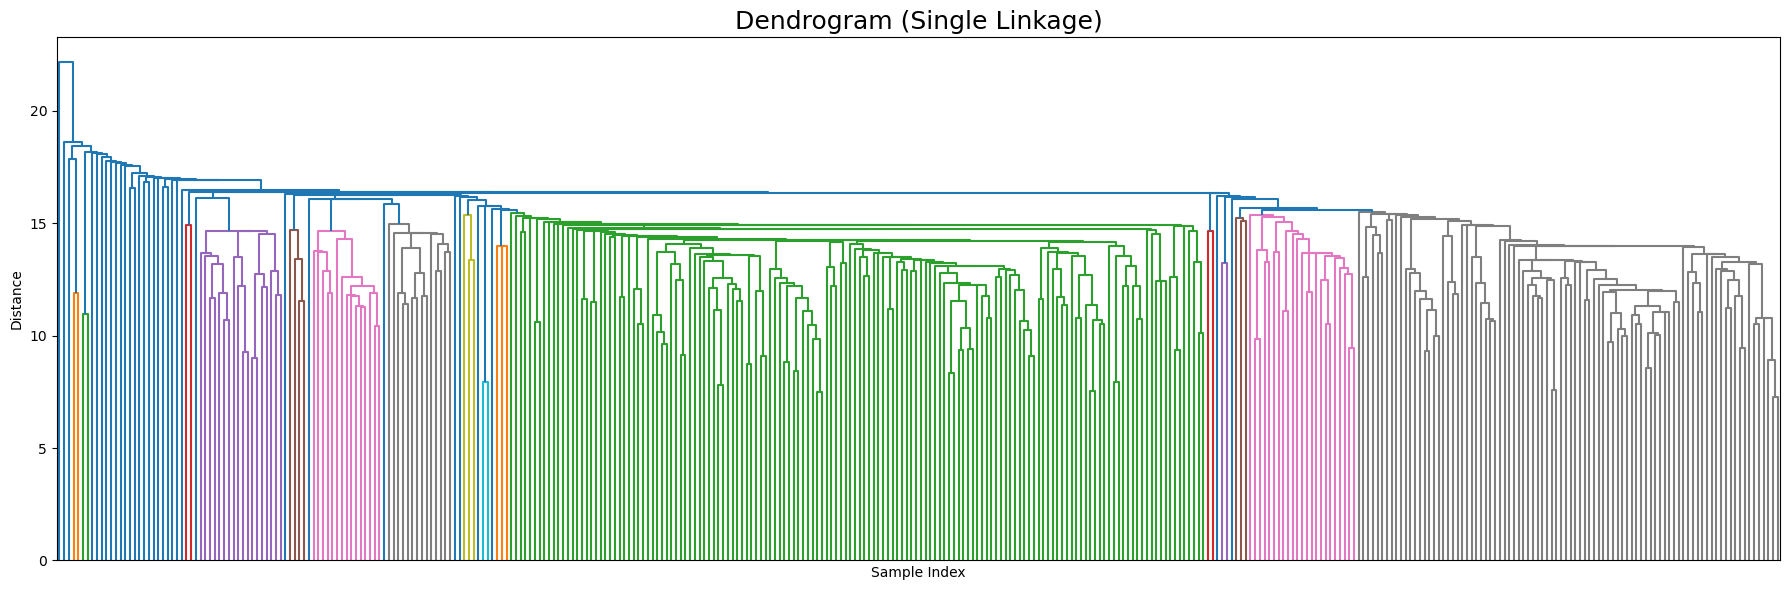

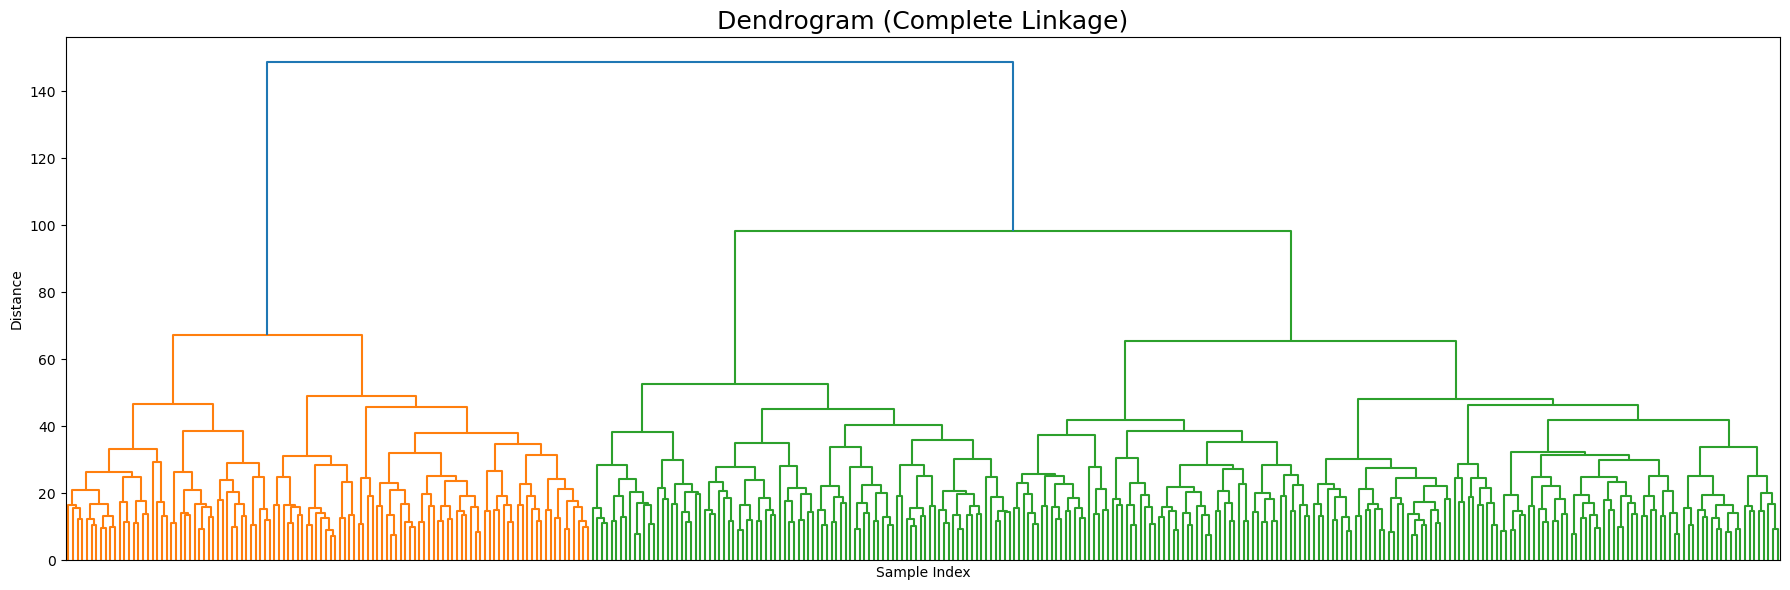

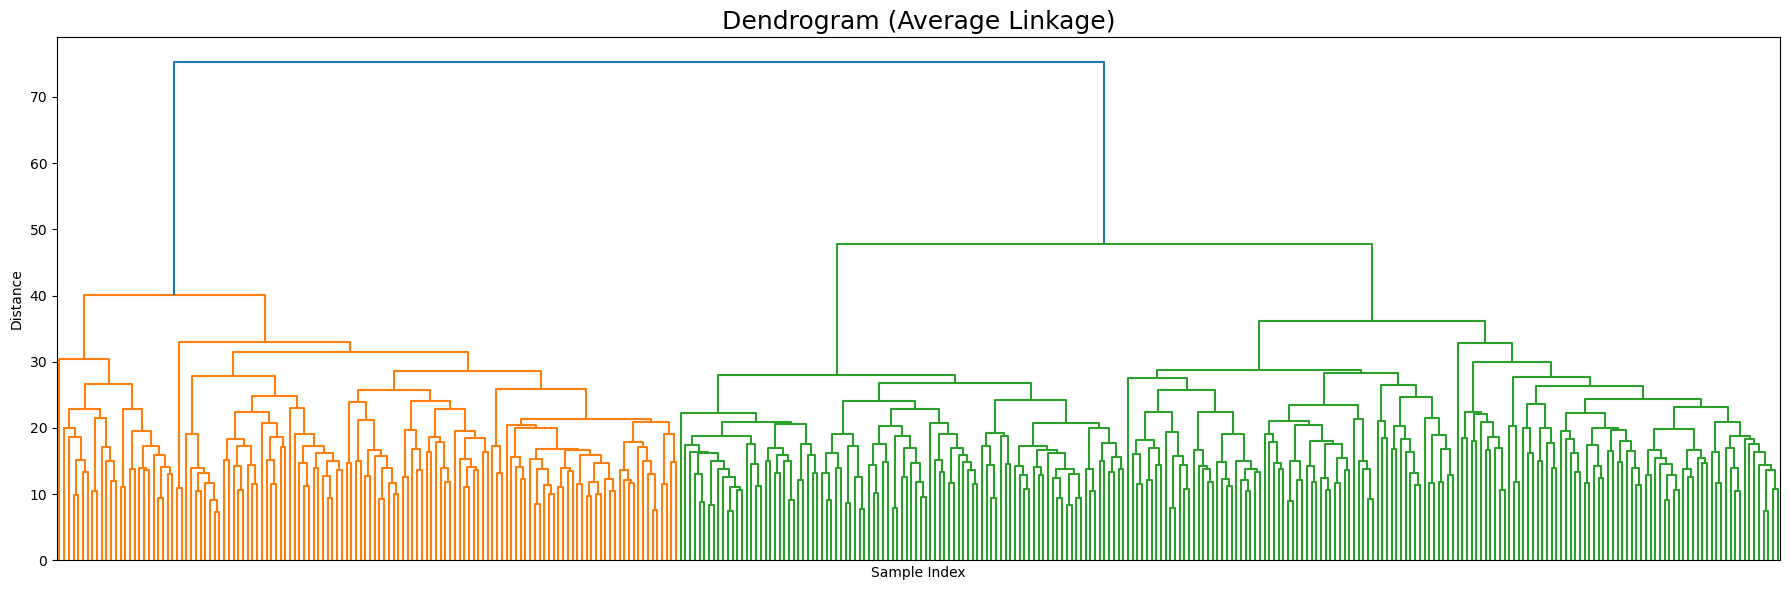

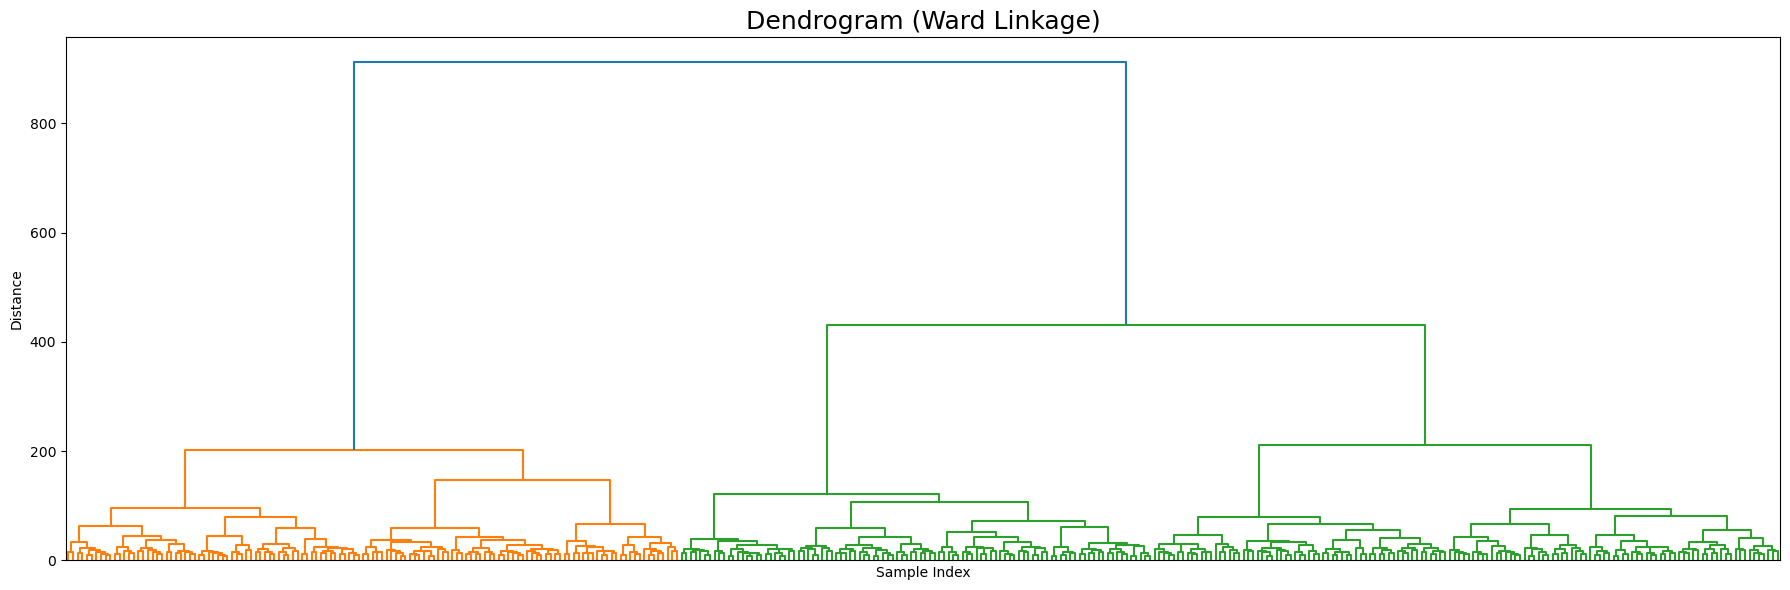

In [140]:
# 2. List of linkage methods
methods = ['single', 'complete', 'average', 'ward']

# 3. Create dendrogram for each method
for method in methods:
    linkage_matrix = linkage(df_weather_2020, method=method)

    plt.figure(figsize=(18, 6))
    dendrogram(linkage_matrix, leaf_rotation=90, no_labels=True)
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=18)
    plt.tight_layout()
    plt.show()

__Comment:__ **Numer of clusters**

- **Single Method**: That is difficult to read, therefore hard to dertermine the exact number of clusters.
- **Complete Method**: Looking at this method shows **2** clusters.
- **Average Method**: Here I can find **2** clusters.
- **Ward Method**: The ward method reveals **2** clusters.

#### Silhouette Score:

In [145]:
methods = ['single', 'complete', 'average', 'ward']
n_clusters = 3  # Or any number you choose for fcluster

for method in methods:
    linkage_matrix = linkage(df_weather_2020, method=method)
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

    score = silhouette_score(df_weather_2020, cluster_labels)
    print(f'Silhouette Score for {method} linkage: {score:.4f}')

Silhouette Score for single linkage: -0.2939
Silhouette Score for complete linkage: 0.3518
Silhouette Score for average linkage: 0.3746
Silhouette Score for ward linkage: 0.3693


## 4.2 Scaled Data

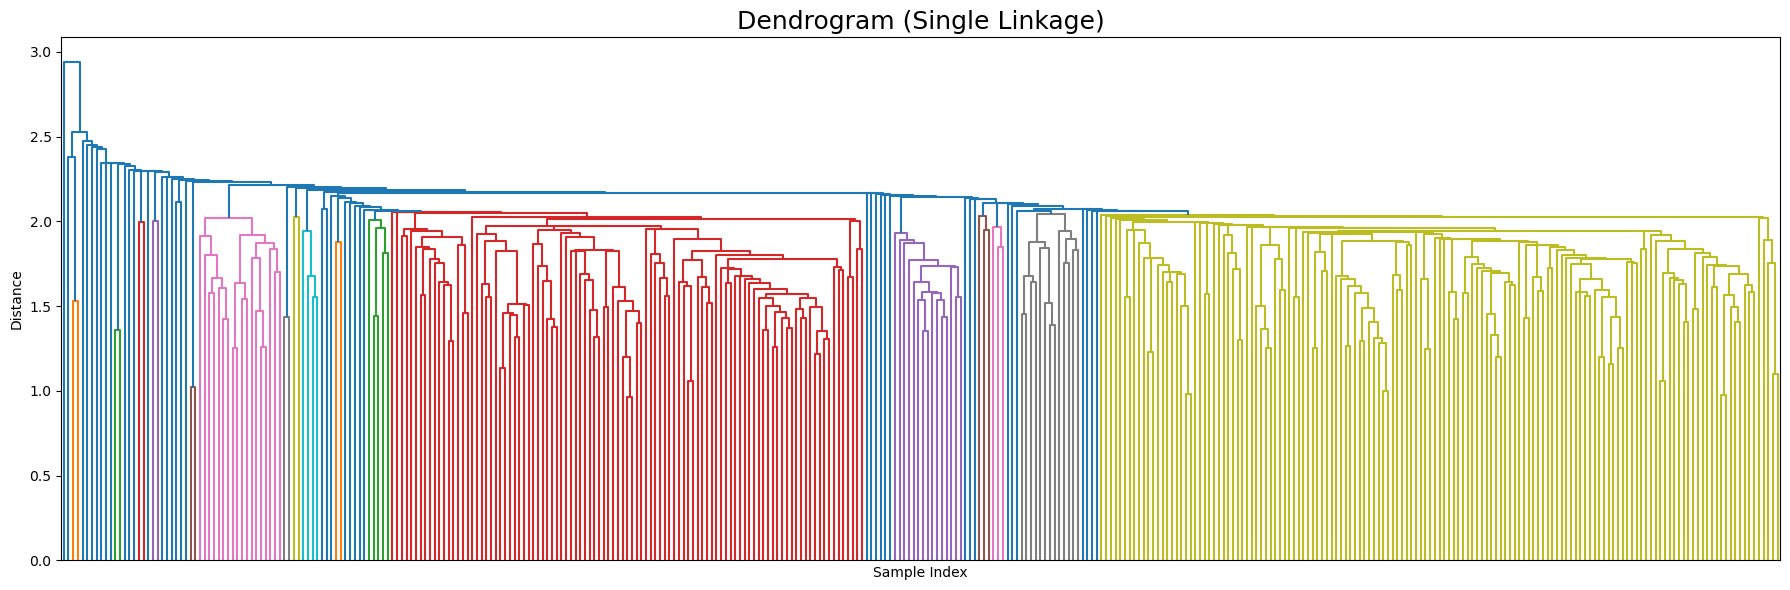

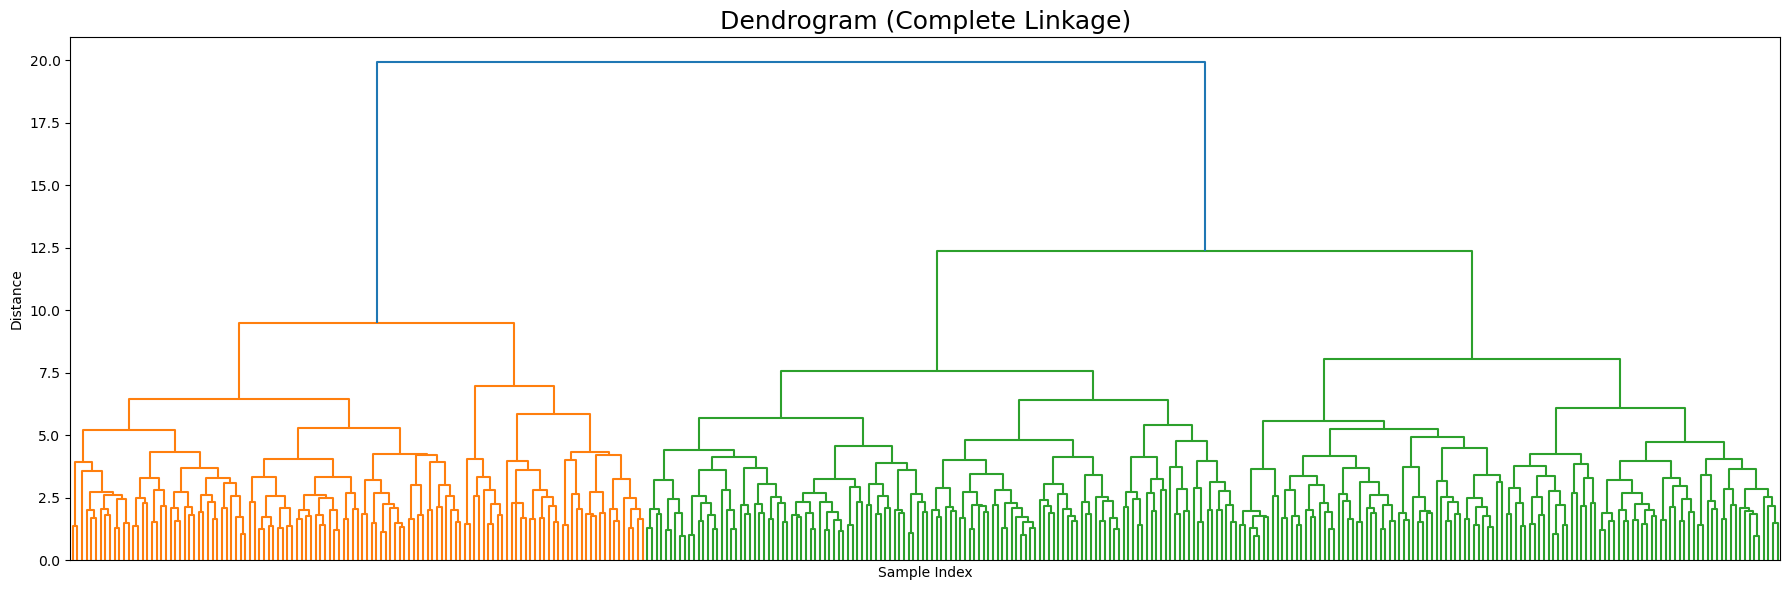

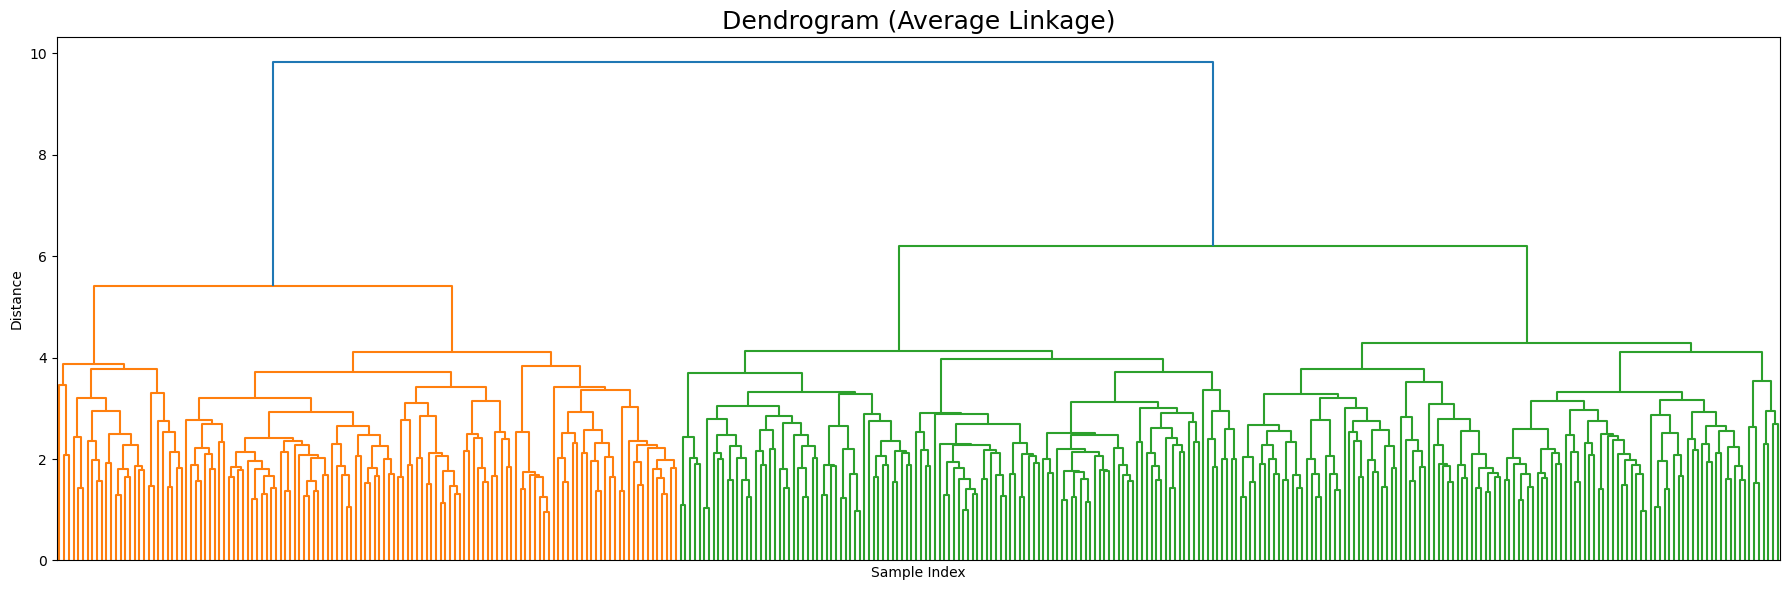

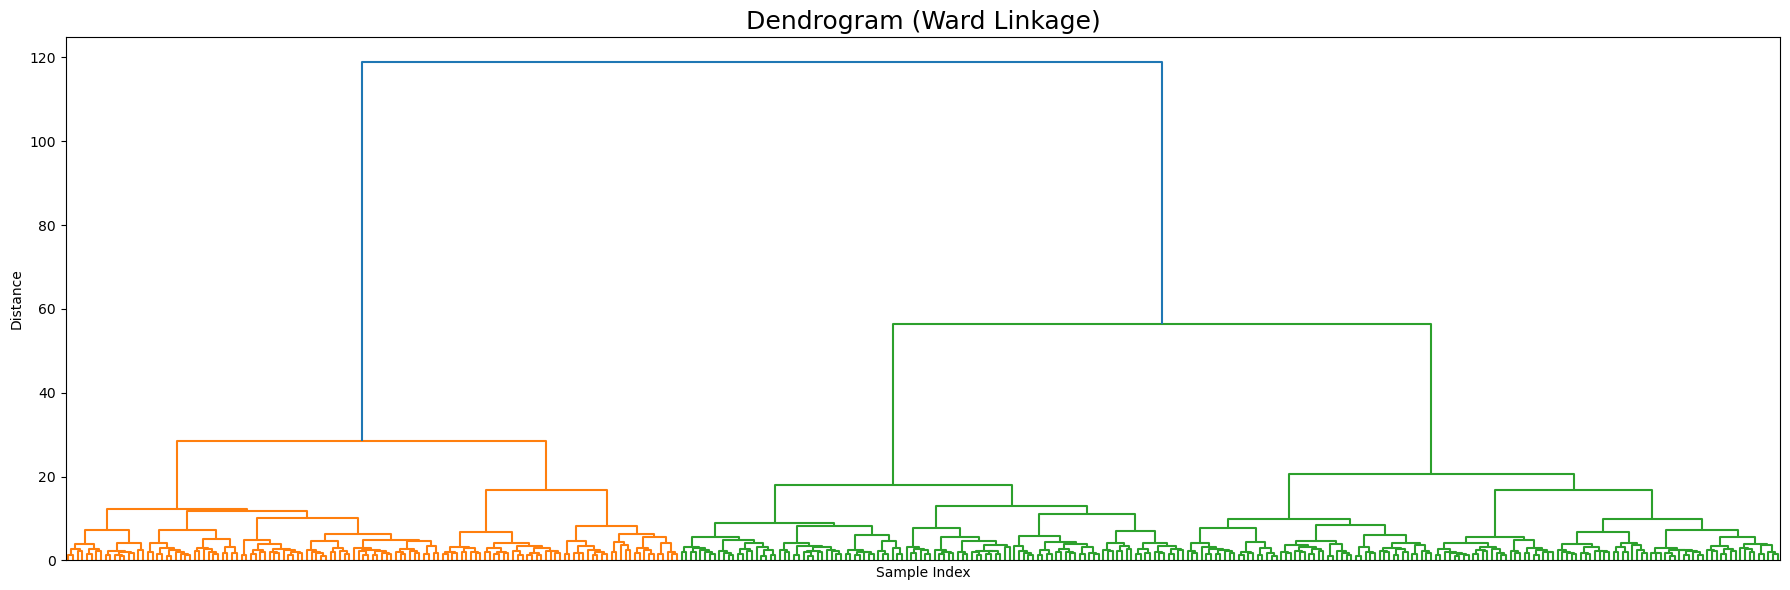

In [142]:
# 2. List of linkage methods
methods = ['single', 'complete', 'average', 'ward']

# 3. Create dendrogram for each method
for method in methods:
    linkage_matrix = linkage(df_weather_2020_scal, method=method)

    plt.figure(figsize=(18, 6))
    dendrogram(linkage_matrix, leaf_rotation=90, no_labels=True)
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=18)
    plt.tight_layout()
    plt.show()

__Comment:__ **Numer of clusters**

- **Single Method**: That is difficult to read, therefore hard to dertermine the exact number of clusters.
- **Complete Method**: Looking at this method shows **2** clusters.
- **Average Method**: Here I can find **2** clusters.
- **Ward Method**: The ward method reveals **2** clusters.

#### Silhouette Score:

In [147]:
methods = ['single', 'complete', 'average', 'ward']
n_clusters = 3  # Or any number you choose for fcluster

for method in methods:
    linkage_matrix = linkage(df_weather_2020_scal, method=method)
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

    score = silhouette_score(df_weather_2020_scal, cluster_labels)
    print(f'Silhouette Score for {method} linkage: {score:.4f}')

Silhouette Score for single linkage: -0.1513
Silhouette Score for complete linkage: 0.3499
Silhouette Score for average linkage: 0.3624
Silhouette Score for ward linkage: 0.3620


# 5. PCA

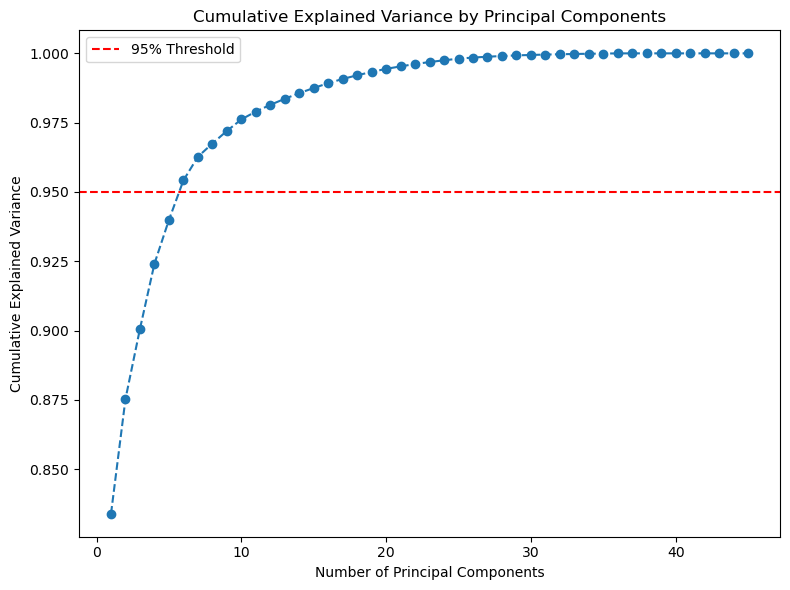

Cumulative Explained Variance: [0.83394473 0.87536536 0.90064933 0.92413294 0.93990507 0.95416618
 0.96269484 0.96747855 0.97200553 0.97616117 0.97900912 0.98142025
 0.98361234 0.98565086 0.98749573 0.98924925 0.99076244 0.99209716
 0.99329231 0.99441312 0.99529767 0.99614987 0.9968615  0.99749932
 0.99807642 0.99848595 0.99878412 0.9990408  0.9992622  0.99942011
 0.99955875 0.99967531 0.99977106 0.99985856 0.9999275  0.99998181
 0.99999929 0.99999969 1.         1.         1.         1.
 1.         1.         1.        ]
Number of components to retain 95% variance: 6


In [187]:
# Apply PCA
pca = PCA()
pca.fit(df_weather_2020_scal)

# Plot cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Components')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')  # Optional: add threshold line for 95%
plt.legend()
plt.tight_layout()
plt.show()

# Output the cumulative explained variance
print(f'Cumulative Explained Variance: {cumulative_variance}')

# Determine the number of components that explain at least 95% of the variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Number of components to retain 95% variance: {n_components_95}')

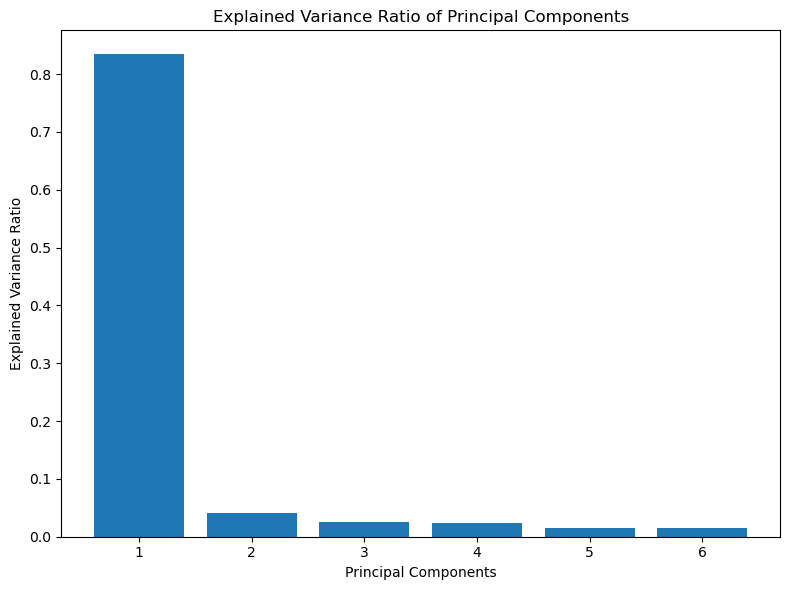

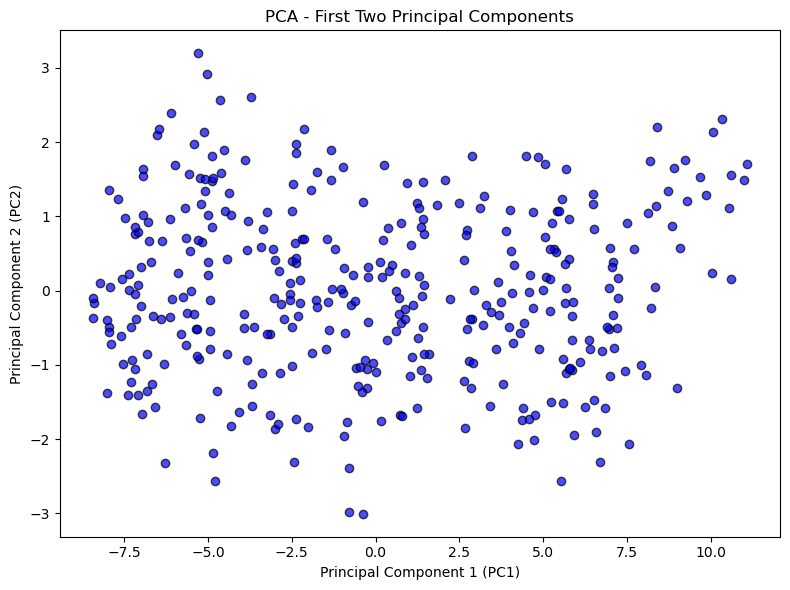

Explained Variance Ratio: [0.83394473 0.04142063 0.02528396 0.02348361 0.01577213 0.01426111]
Cumulative Variance Explained: [0.83394473 0.87536536 0.90064933 0.92413294 0.93990507 0.95416618]


In [183]:
# Apply PCA with 6 components
pca = PCA(n_components=6)
principal_components = pca.fit_transform(df_weather_2020_scal)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(data=principal_components, columns=[f'PC{i+1}' for i in range(6)])

# Visualize the explained variance ratio of each principal component
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.tight_layout()
plt.show()

# Visualize the data points in the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', edgecolors='k', alpha=0.7)
plt.title('PCA - First Two Principal Components')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.tight_layout()
plt.show()

# Print the explained variance ratio and the cumulative variance explained
print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')
print(f'Cumulative Variance Explained: {np.cumsum(pca.explained_variance_ratio_)}')

# Optionally, save the new PCA DataFrame
pca_df.to_csv('pca_weather_data_6_components.csv', index=False)

In [154]:
principal_components

array([[-7.94583430e+00, -4.93634382e-01],
       [-7.17686177e+00,  7.60522236e-01],
       [-6.10287315e+00,  2.39540816e+00],
       [-6.78442819e+00,  9.24676361e-01],
       [-6.94654162e+00,  1.01682706e+00],
       [-6.94990726e+00,  1.63624567e+00],
       [-6.51839651e+00,  2.09395697e+00],
       [-5.29617893e+00,  3.19568174e+00],
       [-3.72141186e+00,  2.61298964e+00],
       [-5.54164829e+00,  5.37681105e-01],
       [-6.71238418e+00,  3.81306400e-01],
       [-5.96918846e+00,  1.68577726e+00],
       [-6.47338341e+00,  2.18323090e+00],
       [-5.03135916e+00,  2.92197548e+00],
       [-4.63217401e+00,  2.56840069e+00],
       [-4.88152806e+00,  1.80955465e+00],
       [-5.41248482e+00,  1.96987573e+00],
       [-7.07721513e+00,  7.82790765e-01],
       [-8.21676165e+00,  9.57891546e-02],
       [-8.38579048e+00, -1.65451237e-01],
       [-8.44368582e+00, -3.65519634e-01],
       [-8.02290940e+00, -3.89377757e-01],
       [-7.93314852e+00,  4.71985994e-02],
       [-7.

In [185]:
#Show new dataframe
pca_df.head(10)

,PC1,PC2,PC3,PC4,PC5,PC6
0,-7.945834,-0.493634,-0.387698,0.079675,1.636560,0.487250
1,-7.176862,0.760522,-0.574724,0.253866,1.791038,0.044059
2,-6.102873,2.395408,-0.843224,-0.650189,0.981979,-0.095471
3,-6.784428,0.924676,-0.003500,-0.374030,-0.083356,0.520355
4,-6.946542,1.016827,-0.035656,0.330550,-1.554250,0.002121
5,-6.949907,1.636246,0.002356,0.078272,0.559507,0.329265
6,-6.518397,2.093957,-0.176039,0.250332,0.814136,0.128865
7,-5.296179,3.195682,-0.140505,0.174386,0.453279,0.227386
8,-3.721412,2.612990,-1.509653,-1.522684,-0.073392,0.692308
9,-5.541648,0.537681,-0.066790,-1.648477,0.135268,0.474192


In [189]:
#Save the new dataframe
pca_df.to_csv(os.path.join(path,'df_weather_pca.csv'))

## 5.1 Dendrogram using PCA Data

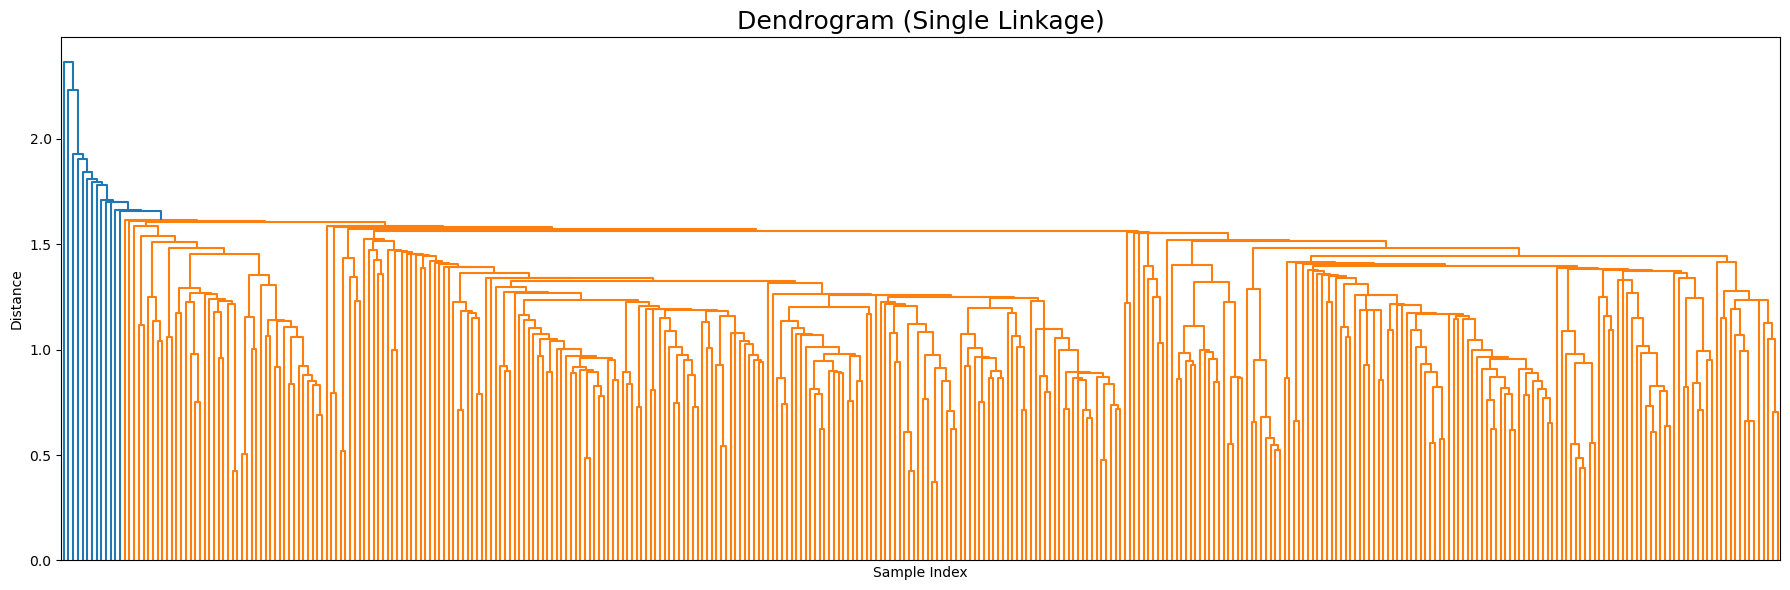

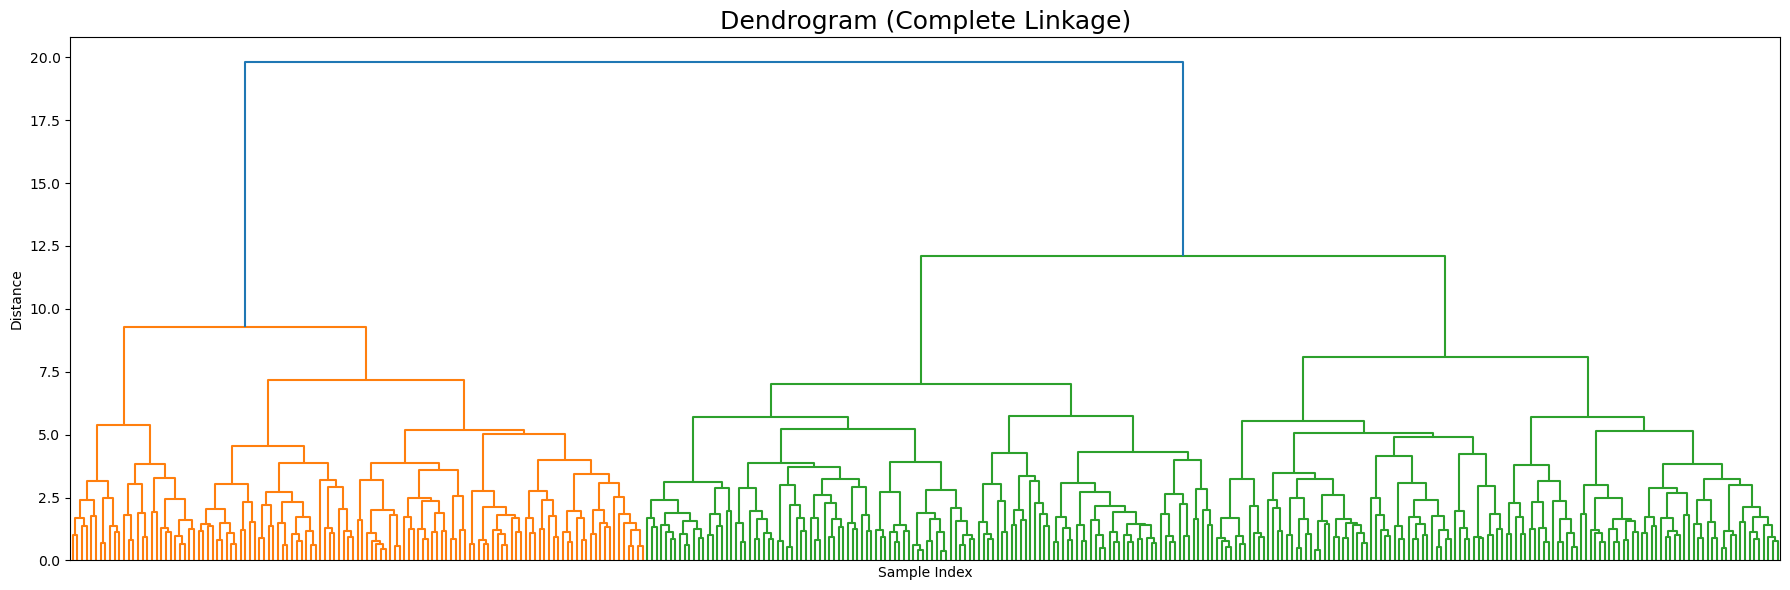

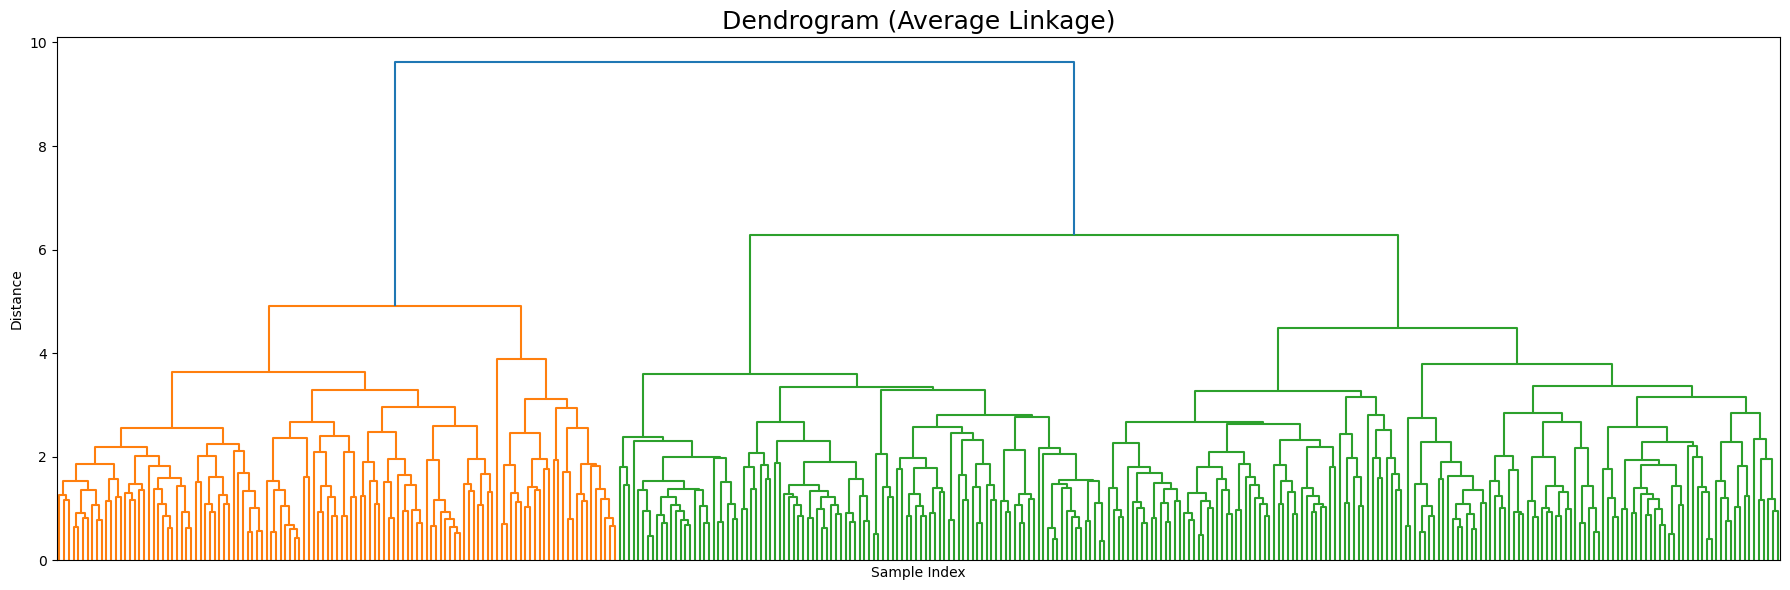

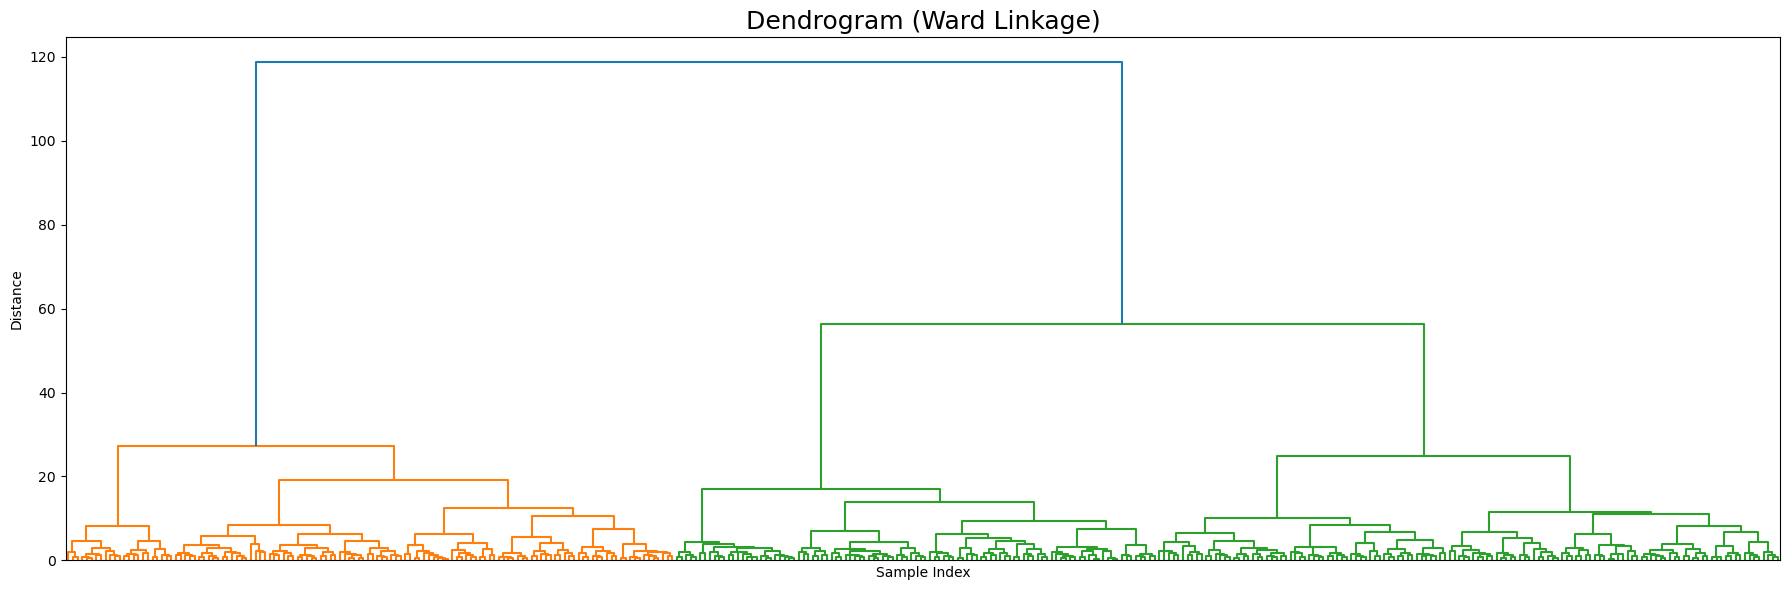

In [191]:
# 1. List of linkage methods
methods = ['single', 'complete', 'average', 'ward']

# 2. Create dendrogram for each method
for method in methods:
    linkage_matrix = linkage(pca_df, method=method)

    plt.figure(figsize=(18, 6))
    dendrogram(linkage_matrix, leaf_rotation=90, no_labels=True)
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.title(f'Dendrogram ({method.capitalize()} Linkage)', fontsize=18)
    plt.tight_layout()
    plt.show()